Starting batch crop of filt_fine.cor files
Input path: /data6/WORKDIR/amatrice2025/merged/interferograms/
Geometry reference path: /data6/WORKDIR/amatrice2025/merged/geom_reference
Output path: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped
Using cropping region: Latitude[42.625, 42.635], Longitude[13.28, 13.3]
Using lat file: /data6/WORKDIR/amatrice2025/merged/geom_reference/lat.rdr
Using lon file: /data6/WORKDIR/amatrice2025/merged/geom_reference/lon.rdr


NameError: name 'read_isce_file' is not defined

In [2]:
   
from mintpy.utils.writefile import * 
from osgeo import gdal  
import os, sys
import numpy as np
import math
import geopandas as gpd
from shapely.geometry import Polygon


## geobbox to SAR row/col in the azimuth&range direction 
def bbox2SAR(lat_min, lat_max, lon_min, lon_max, lat_data, lon_data):
    #  convert geographic bounding box to SAR ROI indicies. (azimuth and range)
    # <1> lat_min (float)     : minimum latitude
    # <2> lat_max (float)     : maximum latitude
    # <3> lon_min (float)     : minimum longitude
    # <4> lon_max (float)     : maximum longitude
    # <5> lat_data (np.array) : the latitude lookuptable lat.rdr  
    # <6> lon_data (np.array) : the lontitude lookuptable lon.rdr
    # <return> region_rec: return the SAR row col list 
    S, N, W, E = lat_min, lat_max, lon_min, lon_max
    geo_coord = [W, N, E, S]
    data_map =  (lon_data >= geo_coord[0])*(lon_data <= geo_coord[2])*(lat_data>=geo_coord[3])*(lat_data<=geo_coord[1])
    region_list = np.argwhere(data_map==1)
    region_rec = [10*math.floor(region_list[:,0].min()/10),10*math.ceil(region_list[:,0].max()/10),\
              10*math.floor(region_list[:,1].min()/10),10*math.ceil(region_list[:,1].max()/10)]
    return region_rec
    
## convert ISCE2 formatted file to npArray
def read_isce_file(file):
    # convert a GDAL_realiable file (usually ISCE2 file) to a numpy array 
    # <1> file(str): a string-path of input file 
    _, ext = os.path.splitext(file)
    ds = gdal.Open(file,gdal.GA_ReadOnly)
    print("input dataset BandsCount : ", ds.RasterCount)
    ## get the phase band for the unw data
    if ext != ".unw":band = ds.GetRasterBand(1)
    else:band = band = ds.GetRasterBand(2)
    data = np.expand_dims(band.ReadAsArray(), 2)
    W, L, N = data.shape
    loader = np.zeros([W, L, N], dtype=np.float32)
    loader[:,:,0] = data[:,:,0]
    return loader


## there may be some problems in the funtion @
## don`t use it 
def write_gdal_file(arr, output_filepath, data_type=gdal.GDT_Float32):
    if len(arr.shape) == 2:
        rows, cols = arr.shape
        bands = 1
        data_to_write = arr
    elif len(arr.shape) == 3:
        rows, cols, bands = arr.shape
        data_to_write = arr[:, :, 0] if bands == 1 else arr
    else:
        raise ValueError("Array must be 2D or 3D")
    driver = gdal.GetDriverByName('ENVI')    
    dataset = driver.Create(output_filepath, cols, rows, 1, data_type)
    if dataset is None:
        raise RuntimeError(f"Could not create file: {output_filepath}")
    if len(arr.shape) == 2:
        dataset.GetRasterBand(1).WriteArray(data_to_write)
    else:
        dataset.GetRasterBand(1).WriteArray(data_to_write[:, :])
    dataset.FlushCache()
    dataset = None
    print(f"GDAL write {output_filepath} finished")


## write np.array to the ISCE2 file according to the input array
def write_arr2file(arr, output_filepath):
    ## write np.array to the ISCE2 file according to the input array
    ## <1> arr(numpy.array) : the numpy array to convert
    ## <2> out_path (str)   : the output path of the arr2ISCEfile
    mirror_dic = {
        ".unw": "MOD_isce_unw", 
        ".cor": "isce_cor", 
        ".rdr": "isce_cor", 
        ".int": "isce_int",
        ".full": "envi"
    }
    _, ext = os.path.splitext(output_filepath)
    if ext == ".full":
        write_gdal_file(arr, output_filepath)
        return
    if ext not in mirror_dic:
        raise ValueError(f"Unsupported file extension: {ext}")
    file_type = mirror_dic[ext]
    write_isce_file(
        data = arr[:,:,0],
        out_file = output_filepath ,
        file_type = file_type
    )
    print(f"write {output_filepath} finished ")

In [4]:
import os
import numpy as np
from osgeo import gdal
import traceback
import re


def batch_crop_filt_fine_cor(base_path, geom_reference_path, output_base_path):
    """
    Batch crop all filt_fine.cor files and simultaneously crop corresponding lat and lon files.
    
    Parameters:
    base_path: The base path containing filt_fine.cor files
    geom_reference_path: The geometry reference path containing lat and lon files
    output_base_path: The base path where cropped files will be saved
    """
    
    # Use the provided latitude and longitude range 13.2, 42.7, 13.4, 42.6
    lat_min, lat_max = 42.6, 42.7
    lon_min, lon_max = 13.2, 13.4
    
    print(f"Using cropping region: Latitude[{lat_min}, {lat_max}], Longitude[{lon_min}, {lon_max}]")
    
    # Look for lat and lon files
    lat_file = os.path.join(geom_reference_path, "lat.rdr")
    lon_file = os.path.join(geom_reference_path, "lon.rdr")
    
    if not os.path.exists(lat_file):
        # Try other possible file names
        lat_files = [f for f in os.listdir(geom_reference_path) if "lat" in f.lower() and not f.startswith('.')]
        if lat_files:
            lat_file = os.path.join(geom_reference_path, lat_files[0])
            print(f"Using found latitude file: {lat_file}")
        else:
            print(f"Error: Could not find lat file in {geom_reference_path}")
            return
    
    if not os.path.exists(lon_file):
        # Try other possible file names
        lon_files = [f for f in os.listdir(geom_reference_path) if "lon" in f.lower() and not f.startswith('.')]
        if lon_files:
            lon_file = os.path.join(geom_reference_path, lon_files[0])
            print(f"Using found longitude file: {lon_file}")
        else:
            print(f"Error: Could not find lon file in {geom_reference_path}")
            return
    
    print(f"Using lat file: {lat_file}")
    print(f"Using lon file: {lon_file}")
    
    # Read lat and lon data
    lat_data = read_isce_file(lat_file)
    lon_data = read_isce_file(lon_file)
    print(f"Lat file shape: {lat_data.shape}")
    print(f"Lon file shape: {lon_data.shape}")
    
    # Calculate the cropping region (SAR coordinates)
    region_rec = bbox2SAR(lat_min, lat_max, lon_min, lon_max, lat_data, lon_data)
    if len(region_rec) != 4:
        print("Invalid region coordinates")
        return
    
    y_min, y_max, x_min, x_max = region_rec
    height = y_max - y_min
    width = x_max - x_min
    print(f"Geographical coordinates converted to SAR coordinates: [{y_min}, {y_max}, {x_min}, {x_max}]")
    print(f"SAR image range: Rows {y_min} to {y_max}, Columns {x_min} to {x_max}")
    print(f"SAR image size: {height} × {width} (Height × Width)")
    
    # Check if the cropping region is valid
    if height <= 0 or width <= 0:
        print("Error: Invalid cropping region, height or width is 0")
        return
    
    # Crop the lat and lon files
    lat_cropped = lat_data[y_min:y_max, x_min:x_max]
    lon_cropped = lon_data[y_min:y_max, x_min:x_max]
    
    # Save the cropped lat and lon files
    lat_output = os.path.join(output_base_path, "lat_cropped.rdr")
    lon_output = os.path.join(output_base_path, "lon_cropped.rdr")
    
    write_arr2file(lat_cropped, lat_output)
    write_arr2file(lon_cropped, lon_output)
    
    print(f"Cropped lat file saved: {lat_output}, shape: {lat_cropped.shape}")
    print(f"Cropped lon file saved: {lon_output}, shape: {lon_cropped.shape}")
    
    # Walk through the directory structure and find filt_fine.cor files
    cor_files = []
    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file == "filt_fine.cor":
                cor_files.append(os.path.join(root, file))
    
    print(f"Found {len(cor_files)} filt_fine.cor files")
    
    # Process each file
    for i, cor_file in enumerate(cor_files):
        print(f"\nProcessing file {i+1}/{len(cor_files)}: {cor_file}")
        
        try:
            # Extract date information from file path
            # Assuming the path format is: .../YYYYMMDD_YYYYMMDD/filt_fine.cor
            date_match = re.search(r'(\d{8}_\d{8})', cor_file)
            if date_match:
                date_str = date_match.group(1)
                print(f"Extracted date information: {date_str}")
            else:
                # If no date is found, use the parent directory name
                parent_dir = os.path.basename(os.path.dirname(cor_file))
                date_str = parent_dir
                print(f"Using parent directory name as date: {date_str}")
            
            # Create the output file name
            output_file = os.path.join(output_base_path, f"{date_str}_filt_fine.cor")
            
            # Check if the output file already exists
            if os.path.exists(output_file):
                print(f"Skipping existing file: {output_file}")
                continue
            
            # Call the cropping function
            crop_single_band_file(
                cor_file, y_min, y_max, x_min, x_max, output_file
            )
            
            print(f"Successfully cropped: {output_file}")
            
        except Exception as e:
            print(f"Error processing file {cor_file}: {str(e)}")
            traceback.print_exc()

def crop_single_band_file(file, y_min, y_max, x_min, x_max, out_file):
    """Crop a single band file (such as filt_fine.cor)"""
    
    # Read data
    data = read_isce_file(file)
    print(f"Original data shape: {data.shape}")
    
    # Check if the cropping region exceeds data boundaries
    data_height, data_width = data.shape[0], data.shape[1]
    if y_max > data_height or x_max > data_width:
        print(f"Warning: Cropping region exceeds data boundaries, adjusting cropping region")
        y_max = min(y_max, data_height)
        x_max = min(x_max, data_width)
        print(f"Adjusted SAR coordinates: [{y_min}, {y_max}, {x_min}, {x_max}]")
    
    # Crop data
    if len(data.shape) == 2:  # Single band data
        data_crop = data[y_min:y_max, x_min:x_max]
    elif len(data.shape) == 3:  # Multi-band data
        data_crop = data[y_min:y_max, x_min:x_max, :]
    else:
        print(f"Unsupported data dimensions: {len(data.shape)}")
        return
    
    print(f"Cropped data shape: {data_crop.shape}")
    
    # Calculate data statistics
    if np.iscomplexobj(data_crop):
        print(f"Complex data range: Min magnitude={np.min(np.abs(data_crop)):.4f}, Max magnitude={np.max(np.abs(data_crop)):.4f}")
    else:
        print(f"Data range: Min={np.min(data_crop):.4f}, Max={np.max(data_crop):.4f}")
    
    # Save cropped data
    if not file.endswith("full"):
        write_arr2file(data_crop, out_file)
    else:
        write_gdal_file(data_crop, out_file)

def main():
    """Main function"""
    
    # Set path parameters
    base_path = "/data6/WORKDIR/amatrice2025/merged/interferograms/"
    geom_reference_path = "/data6/WORKDIR/amatrice2025/merged/geom_reference"
    output_base_path = "/data6/WORKDIR/amatrice2025/merged/interferograms/cropped"  # Output directory
    
    # Ensure the output directory exists
    os.makedirs(output_base_path, exist_ok=True)
    
    print("Starting batch crop of filt_fine.cor files")
    print(f"Input path: {base_path}")
    print(f"Geometry reference path: {geom_reference_path}")
    print(f"Output path: {output_base_path}")
    
    # Execute batch cropping
    batch_crop_filt_fine_cor(
        base_path, geom_reference_path, output_base_path
    )
    
    print("\nBatch cropping complete!")

if __name__ == '__main__':
    main()


Starting batch crop of filt_fine.cor files
Input path: /data6/WORKDIR/amatrice2025/merged/interferograms/
Geometry reference path: /data6/WORKDIR/amatrice2025/merged/geom_reference
Output path: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped
Using cropping region: Latitude[42.6, 42.7], Longitude[13.2, 13.4]
Using lat file: /data6/WORKDIR/amatrice2025/merged/geom_reference/lat.rdr
Using lon file: /data6/WORKDIR/amatrice2025/merged/geom_reference/lon.rdr
input dataset BandsCount :  1
input dataset BandsCount :  1
Lat file shape: (2858, 26031, 1)
Lon file shape: (2858, 26031, 1)
Geographical coordinates converted to SAR coordinates: [340, 1330, 18550, 23950]
SAR image range: Rows 340 to 1330, Columns 18550 to 23950
SAR image size: 990 × 5400 (Height × Width)
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped/lat_cropped.rdr
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped/lat_cropped.rdr.xml
write file: /data6/WORKDIR/amatrice2025/merged/i

In [8]:
import os
path = r"/data6/WORKDIR/amatrice2025/merged/interferograms/cropped/"
dirs = os.listdir( path )
dirs # 读取所有的文件

emp = []
for file in dirs:
    if os.path.splitext(file)[1] == '.cor':   # 只读取固定后缀的文件
        new=file[0:8]  # 截取文件名的前12个字符
        emp.append(new)
        new=file[9:17]  # 截取文件名的前12个字符
        emp.append(new)
import numpy as np
lists = np.unique(emp)
vitarr1 = lists
print(vitarr1)


['20150815' '20150827' '20150920' '20151002' '20151014' '20151026'
 '20151107' '20151201' '20151225' '20160118' '20160211' '20160306'
 '20160330' '20160517' '20160529' '20160610' '20160704' '20160716'
 '20160728' '20160809' '20160821']


In [ ]:
"""
Build Coherence Matrix Dataset for InSAR Time Series Analysis

This script builds coherence matrices from interferogram .cor files.

Matrix Structure:
- Column axis (j): dates[0], dates[1], ..., dates[N-1]  (时间点 0 到 N-1)
- Row axis (i):    dates[1], dates[2], ..., dates[N]    (时间点 1 到 N)
- matrix[i, j] = coherence(dates[j], dates[i+1])

Therefore:
- Diagonal: matrix[i, i] = coherence(dates[i], dates[i+1]) — adjacent time point coherence
- Off-diagonal: matrix[i, j] = coherence(dates[j], dates[i+1])

Label: coherence(dates[N], dates[N+1]) — next adjacent time point coherence
"""

import os
import numpy as np
import pickle
import re
from osgeo import gdal


# ===================== Configuration =====================
CROPPED_DIR = "/data6/WORKDIR/amatrice2025/merged/interferograms/cropped/"
OUTPUT_DIR = "/data6/WORKDIR/amatrice2025/merged/interferograms/cropped/matrix_dataset/"
MATRIX_SIZE = 12  # N: number of columns (and rows)
SLIDE_STEP = 1
USE_AMPLITUDE = True


# ===================== Helper Functions =====================

def get_unique_dates_from_files(cropped_dir, suffix='.cor'):
    """Extract all unique dates from .cor filenames."""
    dates_set = set()
    
    for root, dirs, files in os.walk(cropped_dir):
        for fname in files:
            if not fname.endswith(suffix):
                continue
            match = re.search(r'(\d{8})_(\d{8})', fname)
            if match:
                dates_set.add(match.group(1))
                dates_set.add(match.group(2))
    
    sorted_dates = sorted(list(dates_set))
    print(f"Found {len(sorted_dates)} unique dates:")
    print(sorted_dates)
    return sorted_dates


def find_cor_file(cropped_dir, date1, date2, suffix='filt_fine.cor'):
    """Find the .cor file for a specific date pair."""
    patterns = [f"{date1}_{date2}", f"{date2}_{date1}"]
    
    for root, dirs, files in os.walk(cropped_dir):
        for fname in files:
            if not fname.endswith(suffix):
                continue
            for pattern in patterns:
                if pattern in fname:
                    return os.path.join(root, fname)
    return None


def read_isce_cor_file(filepath, use_amplitude=True):
    """Read ISCE2 coherence file and return as numpy array."""
    ds = gdal.Open(filepath, gdal.GA_ReadOnly)
    if ds is None:
        raise IOError(f"Cannot open file: {filepath}")
    
    band = ds.GetRasterBand(1)
    data = band.ReadAsArray()
    
    if use_amplitude and np.iscomplexobj(data):
        data = np.abs(data)
    
    return data.astype(np.float32)


def get_image_dimensions(cropped_dir, suffix='filt_fine.cor'):
    """Get the dimensions of the coherence images."""
    for root, dirs, files in os.walk(cropped_dir):
        for fname in files:
            if fname.endswith(suffix):
                filepath = os.path.join(root, fname)
                ds = gdal.Open(filepath, gdal.GA_ReadOnly)
                if ds:
                    height = ds.RasterYSize
                    width = ds.RasterXSize
                    print(f"Image dimensions: {height} x {width}")
                    return height, width
    
    raise RuntimeError("No .cor files found to determine image dimensions")


def load_coherence_data(cropped_dir, date1, date2, height, width, suffix='filt_fine.cor'):
    """Load coherence data for a date pair."""
    cor_file = find_cor_file(cropped_dir, date1, date2, suffix)
    
    if cor_file is None:
        return None
    
    cor_data = read_isce_cor_file(cor_file, use_amplitude=USE_AMPLITUDE)
    
    if cor_data.shape != (height, width):
        print(f"  Warning: Shape mismatch. Expected ({height}, {width}), got {cor_data.shape}")
        if cor_data.shape[0] >= height and cor_data.shape[1] >= width:
            cor_data = cor_data[:height, :width]
        else:
            temp = np.zeros((height, width), dtype=np.float32)
            h_min = min(height, cor_data.shape[0])
            w_min = min(width, cor_data.shape[1])
            temp[:h_min, :w_min] = cor_data[:h_min, :w_min]
            cor_data = temp
    
    return cor_data


def build_coherence_matrix_for_sample(dates_for_matrix, cropped_dir, height, width, suffix='filt_fine.cor'):
    """
    Build a coherence matrix for a given set of dates.
    
    dates_for_matrix: List of N+1 dates [d0, d1, d2, ..., dN]
    
    Matrix structure (N x N):
    - Column j corresponds to dates[j] (j = 0, 1, ..., N-1)
    - Row i corresponds to dates[i+1] (i = 0, 1, ..., N-1)
    - matrix[i, j] = coherence(dates[j], dates[i+1])
    
    Diagonal: matrix[i, i] = coherence(dates[i], dates[i+1]) — adjacent coherence
    
    Args:
        dates_for_matrix: List of N+1 date strings
        cropped_dir: Directory containing .cor files
        height, width: Image dimensions
        suffix: File suffix to match
        
    Returns:
        4D numpy array (H, W, N, N)
    """
    n_dates_total = len(dates_for_matrix)  # N+1 dates
    N = n_dates_total - 1  # Matrix size N x N
    
    # Initialize with zeros
    matrix = np.zeros((height, width, N, N), dtype=np.float32)
    
    print(f"  Building {N}x{N} coherence matrix")
    print(f"  Column dates (j=0..{N-1}): {dates_for_matrix[0]} to {dates_for_matrix[N-1]}")
    print(f"  Row dates (i=0..{N-1}):    {dates_for_matrix[1]} to {dates_for_matrix[N]}")
    
    # Fill lower triangle and diagonal
    # matrix[i, j] = coherence(dates[j], dates[i+1])
    # Only fill where i >= j (lower triangle including diagonal)
    for i in range(N):  # row index
        for j in range(i + 1):  # column index, only up to i (lower triangle)
            date_col = dates_for_matrix[j]      # Column date: dates[j]
            date_row = dates_for_matrix[i + 1]  # Row date: dates[i+1]
            
            cor_data = load_coherence_data(cropped_dir, date_col, date_row, height, width, suffix)
            
            if cor_data is not None:
                matrix[:, :, i, j] = cor_data
                if i == j:
                    print(f"    Diagonal [{i},{j}]: coherence({date_col}, {date_row})")
            else:
                if i == j:
                    print(f"    Warning: No file for diagonal [{i},{j}]: {date_col} - {date_row}")
    
    # Copy lower triangle to upper triangle (make symmetric)
    print("  Making matrix symmetric (copying lower triangle to upper triangle)...")
    for i in range(N):
        for j in range(i + 1, N):
            matrix[:, :, i, j] = matrix[:, :, j, i]
    
    return matrix


def build_dataset(cropped_dir, output_dir, matrix_size=12, slide_step=1, suffix='filt_fine.cor'):
    """
    Build the complete coherence matrix dataset with labels.
    
    For matrix_size = N:
    - Need N+1 dates for the matrix: [d0, d1, ..., dN]
      - Columns: d0, d1, ..., d(N-1)
      - Rows: d1, d2, ..., dN
    - Need 1 more date for label: d(N+1)
      - Label = coherence(dN, d(N+1))
    - Total: N+2 dates per sample
    """
    os.makedirs(output_dir, exist_ok=True)
    
    N = matrix_size
    
    # Get all unique dates
    all_dates = get_unique_dates_from_files(cropped_dir, suffix='.cor')
    
    # Need N+2 dates per sample
    if len(all_dates) < N + 2:
        raise ValueError(f"Not enough dates ({len(all_dates)}) for matrix size {N} (need {N+2} dates)")
    
    # Get image dimensions
    height, width = get_image_dimensions(cropped_dir, suffix)
    
    # Calculate number of samples
    n_samples = (len(all_dates) - N - 1) // slide_step
    print(f"\nWill create {n_samples} samples with matrix size {N}x{N}")
    print(f"Each sample uses {N+1} dates for matrix + 1 date for label = {N+2} dates")
    
    samples_info = []
    
    for sample_idx in range(n_samples):
        start_idx = sample_idx * slide_step
        
        # Dates for matrix: [d0, d1, ..., dN] — total N+1 dates
        dates_for_matrix = all_dates[start_idx : start_idx + N + 1]
        
        # Date for label: d(N+1)
        label_date = all_dates[start_idx + N + 1]
        
        print(f"\n{'='*70}")
        print(f"Sample {sample_idx + 1}/{n_samples}")
        print(f"Matrix dates: {dates_for_matrix[0]} to {dates_for_matrix[-1]} ({len(dates_for_matrix)} dates)")
        print(f"Label: coherence({dates_for_matrix[-1]}, {label_date})")
        print(f"{'='*70}")
        
        # Build coherence matrix
        matrix = build_coherence_matrix_for_sample(dates_for_matrix, cropped_dir, height, width, suffix)
        
        # Build label: coherence(dN, d(N+1))
        print(f"  Loading label: coherence({dates_for_matrix[-1]}, {label_date})")
        label = load_coherence_data(cropped_dir, dates_for_matrix[-1], label_date, height, width, suffix)
        if label is None:
            print(f"  Warning: No label file found!")
            label = np.zeros((height, width), dtype=np.float32)
        
        # Save sample
        sample_name = f"{dates_for_matrix[-1]}_{label_date}"
        
        matrix_path = os.path.join(output_dir, f"{sample_name}_matrix.npy")
        np.save(matrix_path, matrix)
        print(f"Saved matrix: {matrix_path}")
        print(f"Matrix shape: {matrix.shape}")
        
        label_path = os.path.join(output_dir, f"{sample_name}_label.npy")
        np.save(label_path, label)
        print(f"Saved label: {label_path}")
        print(f"Label shape: {label.shape}")
        
        samples_info.append({
            'sample_idx': sample_idx,
            'sample_name': sample_name,
            'dates_for_matrix': dates_for_matrix,
            'column_dates': dates_for_matrix[:-1],  # d0 to d(N-1)
            'row_dates': dates_for_matrix[1:],       # d1 to dN
            'label_dates': (dates_for_matrix[-1], label_date),
            'matrix_file': f"{sample_name}_matrix.npy",
            'label_file': f"{sample_name}_label.npy"
        })
    
    # Save metadata
    metadata = {
        'n_samples': n_samples,
        'matrix_size': N,
        'slide_step': slide_step,
        'image_height': height,
        'image_width': width,
        'all_dates': all_dates,
        'samples': samples_info,
        'matrix_structure': {
            'description': 'matrix[i, j] = coherence(dates[j], dates[i+1])',
            'column_axis': 'dates[0], dates[1], ..., dates[N-1]',
            'row_axis': 'dates[1], dates[2], ..., dates[N]',
            'diagonal': 'matrix[i, i] = coherence(dates[i], dates[i+1]) — adjacent coherence',
            'label': 'coherence(dates[N], dates[N+1]) — next adjacent coherence'
        }
    }
    
    metadata_path = os.path.join(output_dir, 'dataset_metadata.pkl')
    with open(metadata_path, 'wb') as f:
        pickle.dump(metadata, f)
    print(f"\nSaved metadata: {metadata_path}")
    
    # Save readable info
    info_path = os.path.join(output_dir, 'dataset_info.txt')
    with open(info_path, 'w') as f:
        f.write("Coherence Matrix Dataset Information\n")
        f.write("=" * 60 + "\n\n")
        f.write(f"Number of samples: {n_samples}\n")
        f.write(f"Matrix size: {N} x {N}\n")
        f.write(f"Slide step: {slide_step}\n")
        f.write(f"Image dimensions: {height} x {width}\n")
        f.write(f"Matrix shape per sample: ({height}, {width}, {N}, {N})\n")
        f.write(f"Label shape per sample: ({height}, {width})\n\n")
        f.write("Matrix Structure:\n")
        f.write("  - Column axis (j): dates[0], dates[1], ..., dates[N-1]\n")
        f.write("  - Row axis (i):    dates[1], dates[2], ..., dates[N]\n")
        f.write("  - matrix[i, j] = coherence(dates[j], dates[i+1])\n")
        f.write("  - Diagonal[i, i] = coherence(dates[i], dates[i+1]) — adjacent coherence\n")
        f.write("  - Label = coherence(dates[N], dates[N+1])\n\n")
        f.write(f"All dates ({len(all_dates)}):\n")
        for d in all_dates:
            f.write(f"  {d}\n")
        f.write("\nSamples:\n")
        for info in samples_info:
            f.write(f"\n  Sample {info['sample_idx'] + 1}: {info['sample_name']}\n")
            f.write(f"    Column dates: {info['column_dates'][0]} to {info['column_dates'][-1]}\n")
            f.write(f"    Row dates:    {info['row_dates'][0]} to {info['row_dates'][-1]}\n")
            f.write(f"    Label: coherence({info['label_dates'][0]}, {info['label_dates'][1]})\n")
    
    print(f"Saved info: {info_path}")
    print(f"\nDataset creation complete!")
    
    return metadata


def load_sample(output_dir, sample_name):
    """Load a single sample."""
    matrix = np.load(os.path.join(output_dir, f"{sample_name}_matrix.npy"))
    label = np.load(os.path.join(output_dir, f"{sample_name}_label.npy"))
    return matrix, label


# ===================== Main Entry Point =====================

if __name__ == "__main__":
    print("Building Coherence Matrix Dataset")
    print("=" * 70)
    print(f"Input directory: {CROPPED_DIR}")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"Matrix size: {MATRIX_SIZE} x {MATRIX_SIZE}")
    print(f"Slide step: {SLIDE_STEP}")
    print("\nMatrix Structure:")
    print("  - Column axis (j): dates[0], dates[1], ..., dates[N-1]")
    print("  - Row axis (i):    dates[1], dates[2], ..., dates[N]")
    print("  - matrix[i, j] = coherence(dates[j], dates[i+1])")
    print("  - Diagonal = adjacent time coherences")
    print("=" * 70)
    
    metadata = build_dataset(
        cropped_dir=CROPPED_DIR,
        output_dir=OUTPUT_DIR,
        matrix_size=MATRIX_SIZE,
        slide_step=SLIDE_STEP,
        suffix='filt_fine.cor'
    )
    
    # Verify
    if metadata['n_samples'] > 0:
        first_sample = metadata['samples'][0]
        matrix, label = load_sample(OUTPUT_DIR, first_sample['sample_name'])
        print(f"\nVerification - First sample '{first_sample['sample_name']}':")
        print(f"  Matrix shape: {matrix.shape}")
        print(f"  Label shape: {label.shape}")
        print(f"\n  Diagonal statistics (adjacent coherences):")
        for i in range(min(5, matrix.shape[2])):
            diag_vals = matrix[:, :, i, i]
            print(f"    Diagonal[{i},{i}]: mean={diag_vals.mean():.4f}, "
                  f"min={diag_vals.min():.4f}, max={diag_vals.max():.4f}")

Building Coherence Matrix Dataset
Input directory: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped/
Output directory: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped/matrix_dataset/
Matrix size: 12 x 12
Slide step: 1

Matrix Structure:
  - Column axis (j): dates[0], dates[1], ..., dates[N-1]
  - Row axis (i):    dates[1], dates[2], ..., dates[N]
  - matrix[i, j] = coherence(dates[j], dates[i+1])
  - Diagonal = adjacent time coherences
Found 22 unique dates:
['20150815', '20150827', '20150920', '20151002', '20151014', '20151026', '20151107', '20151201', '20151225', '20160118', '20160211', '20160306', '20160330', '20160517', '20160529', '20160610', '20160704', '20160716', '20160728', '20160809', '20160821', '20160914']
Image dimensions: 990 x 5400

Will create 9 samples with matrix size 12x12
Each sample uses 13 dates for matrix + 1 date for label = 14 dates

Sample 1/9
Matrix dates: 20150815 to 20160330 (13 dates)
Label: coherence(20160330, 20160517)
  Building 12x12

    Diagonal [0,0]: coherence(20150815, 20150827)
    Diagonal [1,1]: coherence(20150827, 20150920)
    Diagonal [2,2]: coherence(20150920, 20151002)
    Diagonal [3,3]: coherence(20151002, 20151014)
    Diagonal [4,4]: coherence(20151014, 20151026)
    Diagonal [5,5]: coherence(20151026, 20151107)
    Diagonal [6,6]: coherence(20151107, 20151201)
    Diagonal [7,7]: coherence(20151201, 20151225)
    Diagonal [8,8]: coherence(20151225, 20160118)
    Diagonal [9,9]: coherence(20160118, 20160211)
    Diagonal [10,10]: coherence(20160211, 20160306)
    Diagonal [11,11]: coherence(20160306, 20160330)
  Making matrix symmetric (copying lower triangle to upper triangle)...
  Loading label: coherence(20160330, 20160517)
Saved matrix: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped/matrix_dataset/20160330_20160517_matrix.npy
Matrix shape: (990, 5400, 12, 12)
Saved label: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped/matrix_dataset/20160330_20160517_label.npy
Label shape: 

Loading matrix: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped/matrix_dataset/20160821_20160914_matrix.npy
Matrix shape: (990, 5400, 12, 12)
Loading label: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped/matrix_dataset/20160821_20160914_label.npy
Label shape: (990, 5400)

像素 (500, 2700) 的相干矩阵:
[[0.3113021  0.47373888 0.40185976 0.24370226 0.3917352  0.401879
  0.39206252 0.39344892 0.27785638 0.31515414 0.30507633 0.44138336]
 [0.47373888 0.31801724 0.5830778  0.39253718 0.39030004 0.30392843
  0.3877121  0.2812135  0.35819352 0.38715756 0.5023826  0.3721763 ]
 [0.40185976 0.5830778  0.38019252 0.26101965 0.24563554 0.26303965
  0.3193908  0.20435065 0.3590657  0.30639696 0.23952547 0.3335536 ]
 [0.24370226 0.39253718 0.26101965 0.40478933 0.28859892 0.424352
  0.36639875 0.3645526  0.30699065 0.31810203 0.337486   0.4331148 ]
 [0.3917352  0.39030004 0.24563554 0.28859892 0.21693783 0.30957308
  0.31845465 0.28963298 0.5704417  0.32054928 0.2603079  0.5509863 ]
 [0

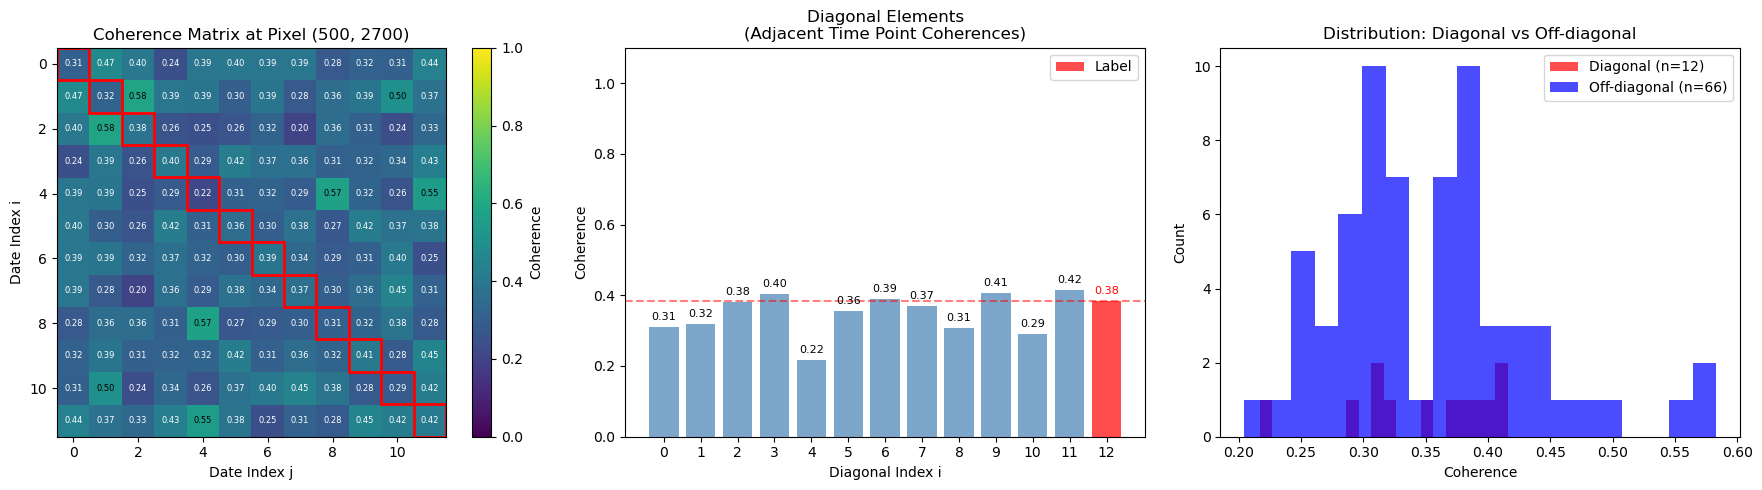

2026-01-07 14:17:15,001 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fc0f848feb0>
2026-01-07 14:17:15,213 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fc0f8722af0>
2026-01-07 14:17:15,422 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fc0f8b48310>
2026-01-07 14:17:15,637 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fc0f8643dc0>
2026-01-07 14:17:15,853 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fc0f8c7a9d0>
2026-01-07 14:17:16,070 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fc0f850f3d0>
2026-01-07 14:17:16,285 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fc0f868dee0>
2026-01-07 14:17:16,344 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fc0f86e5af0>
Saved: spatial_diagonal_

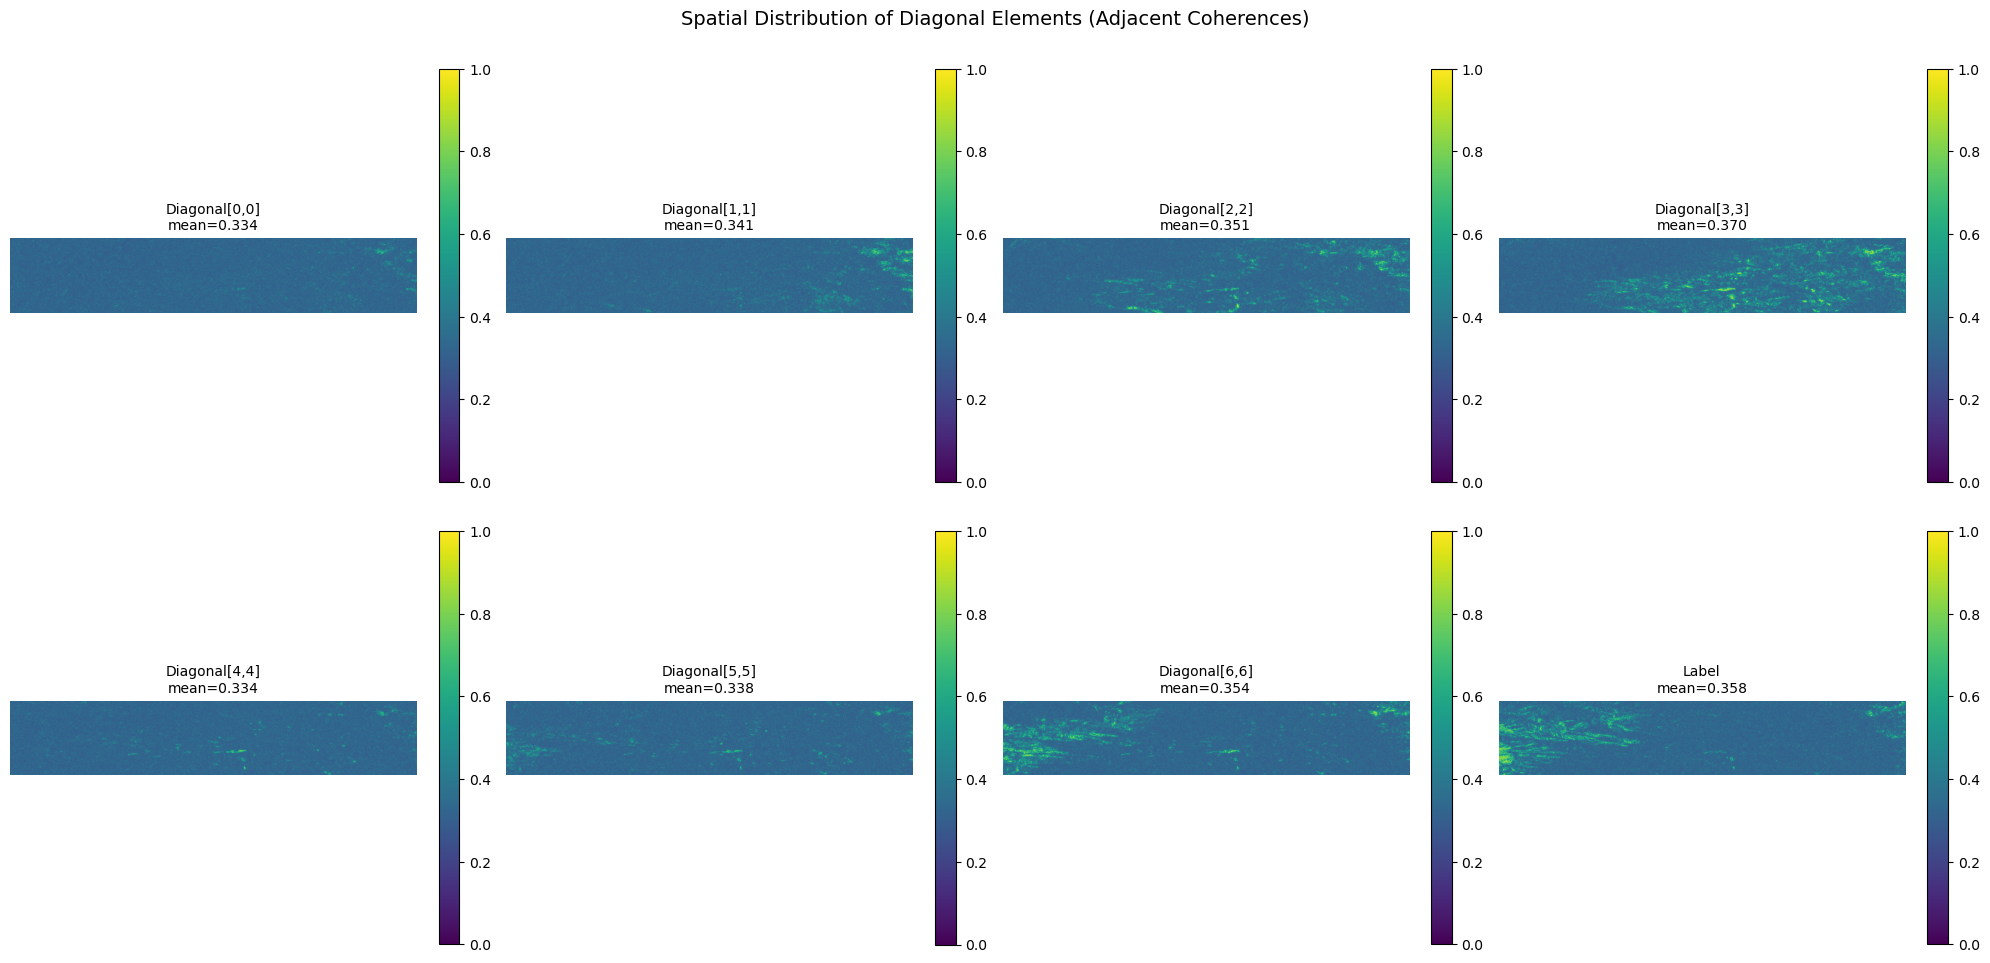

2026-01-07 14:17:21,176 - matplotlib.colorbar - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x7fc0f8446940>
Saved: matrix_statistics.png


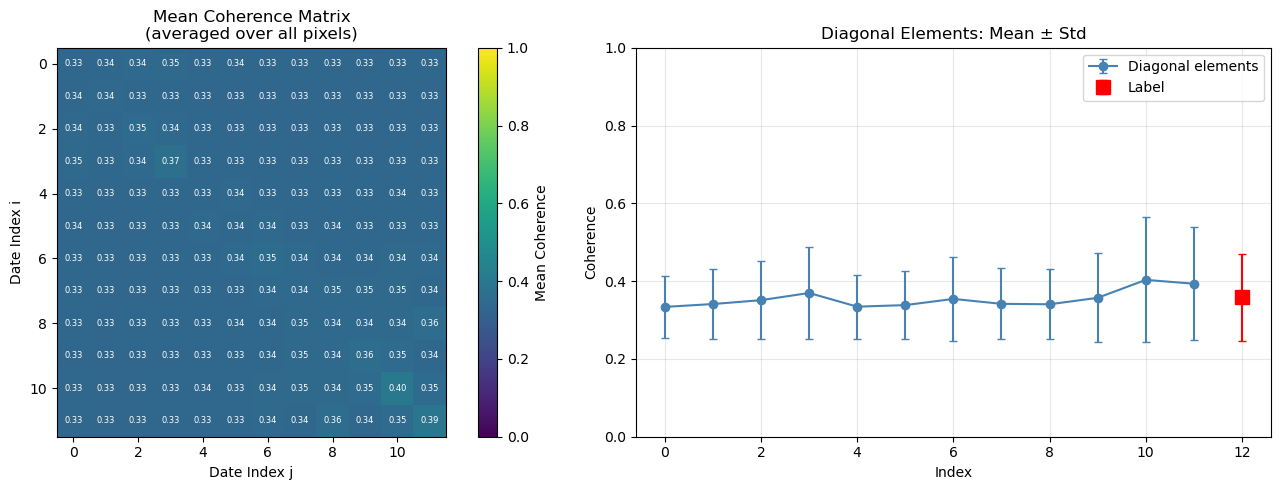


矩阵统计信息

对角线元素 (相邻时间点相干性):
  Diagonal[ 0, 0]: mean=0.3337, std=0.0804, min=0.1467, max=0.9743
  Diagonal[ 1, 1]: mean=0.3411, std=0.0895, min=0.1545, max=0.9866
  Diagonal[ 2, 2]: mean=0.3511, std=0.1004, min=0.1504, max=0.9936
  Diagonal[ 3, 3]: mean=0.3695, std=0.1186, min=0.1512, max=0.9989
  Diagonal[ 4, 4]: mean=0.3343, std=0.0821, min=0.1527, max=0.9904
  Diagonal[ 5, 5]: mean=0.3384, std=0.0866, min=0.1483, max=0.9865
  Diagonal[ 6, 6]: mean=0.3542, std=0.1085, min=0.1504, max=0.9929
  Diagonal[ 7, 7]: mean=0.3416, std=0.0914, min=0.1513, max=0.9766
  Diagonal[ 8, 8]: mean=0.3405, std=0.0895, min=0.1511, max=0.9641
  Diagonal[ 9, 9]: mean=0.3571, std=0.1146, min=0.1516, max=0.9895
  Diagonal[10,10]: mean=0.4032, std=0.1609, min=0.1515, max=0.9962
  Diagonal[11,11]: mean=0.3934, std=0.1451, min=0.1548, max=0.9939

Label: mean=0.3582, std=0.1114, min=0.1489, max=0.9861

非对角线元素统计 (部分):
  [ 0, 2]: mean=0.3417, std=0.0904
  [ 0, 3]: mean=0.3465, std=0.0973
  [ 0, 4]: mean=0.3325, std

In [18]:
"""
直接可视化已保存的相干矩阵 .npy 文件
"""

import numpy as np
import matplotlib.pyplot as plt


# ===================== 配置 =====================
# 矩阵文件路径
MATRIX_FILE = "/data6/WORKDIR/amatrice2025/merged/interferograms/cropped/matrix_dataset/20160821_20160914_matrix.npy"

# 对应的 label 文件路径
LABEL_FILE = "/data6/WORKDIR/amatrice2025/merged/interferograms/cropped/matrix_dataset/20160821_20160914_label.npy"

# 要检查的像素位置
PIXEL_ROW = 500
PIXEL_COL = 2700


def visualize_matrix(matrix_file, label_file=None, pixel_row=500, pixel_col=500):
    """可视化相干矩阵"""
    
    # 加载数据
    print(f"Loading matrix: {matrix_file}")
    matrix = np.load(matrix_file)
    print(f"Matrix shape: {matrix.shape}")  # (H, W, N, N)
    
    if label_file:
        print(f"Loading label: {label_file}")
        label = np.load(label_file)
        print(f"Label shape: {label.shape}")  # (H, W)
    else:
        label = None
    
    H, W, N, N2 = matrix.shape
    
    # 检查像素位置是否有效
    if pixel_row >= H or pixel_col >= W:
        print(f"Warning: Pixel ({pixel_row}, {pixel_col}) out of bounds. Using (H//2, W//2)")
        pixel_row, pixel_col = H // 2, W // 2
    
    # 提取单像素的相干矩阵
    pixel_matrix = matrix[pixel_row, pixel_col, :, :]
    pixel_label = label[pixel_row, pixel_col] if label is not None else None
    
    print(f"\n像素 ({pixel_row}, {pixel_col}) 的相干矩阵:")
    print(pixel_matrix)
    
    # ==================== 图1: 单像素相干矩阵 ====================
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # 左: 相干矩阵热图
    ax1 = axes[0]
    im1 = ax1.imshow(pixel_matrix, cmap='viridis', vmin=0, vmax=1)
    ax1.set_title(f'Coherence Matrix at Pixel ({pixel_row}, {pixel_col})', fontsize=12)
    ax1.set_xlabel('Date Index j')
    ax1.set_ylabel('Date Index i')
    plt.colorbar(im1, ax=ax1, label='Coherence')
    
    # 在每个格子中显示数值
    for i in range(N):
        for j in range(N):
            color = 'white' if pixel_matrix[i, j] < 0.5 else 'black'
            ax1.text(j, i, f'{pixel_matrix[i, j]:.2f}', ha='center', va='center', 
                    fontsize=6, color=color)
    
    # 高亮对角线
    for i in range(N):
        rect = plt.Rectangle((i-0.5, i-0.5), 1, 1, fill=False, 
                             edgecolor='red', linewidth=2)
        ax1.add_patch(rect)
    
    # 中: 对角线元素柱状图
    ax2 = axes[1]
    diagonal_values = np.diag(pixel_matrix)
    x_positions = np.arange(N)
    
    bars = ax2.bar(x_positions, diagonal_values, color='steelblue', alpha=0.7)
    
    # 添加 label
    if pixel_label is not None:
        ax2.bar(N, pixel_label, color='red', alpha=0.7, label='Label')
        ax2.axhline(pixel_label, color='red', linestyle='--', alpha=0.5)
    
    ax2.set_xlabel('Diagonal Index i')
    ax2.set_ylabel('Coherence')
    ax2.set_title('Diagonal Elements\n(Adjacent Time Point Coherences)', fontsize=12)
    ax2.set_ylim(0, 1.1)
    ax2.set_xticks(range(N + (1 if pixel_label is not None else 0)))
    
    # 添加数值标注
    for i, v in enumerate(diagonal_values):
        ax2.text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=8)
    if pixel_label is not None:
        ax2.text(N, pixel_label + 0.02, f'{pixel_label:.2f}', ha='center', fontsize=8, color='red')
    
    ax2.legend()
    
    # 右: 对角线 vs 非对角线分布
    ax3 = axes[2]
    diag_vals = diagonal_values
    off_diag_vals = pixel_matrix[np.triu_indices(N, k=1)]  # 上三角（不含对角线）
    
    ax3.hist(diag_vals, bins=20, alpha=0.7, label=f'Diagonal (n={len(diag_vals)})', color='red')
    ax3.hist(off_diag_vals, bins=20, alpha=0.7, label=f'Off-diagonal (n={len(off_diag_vals)})', color='blue')
    ax3.set_xlabel('Coherence')
    ax3.set_ylabel('Count')
    ax3.set_title('Distribution: Diagonal vs Off-diagonal', fontsize=12)
    ax3.legend()
    
    plt.tight_layout()

    print("\nSaved: pixel_matrix_view.png")
    plt.show()
    
    # ==================== 图2: 空间分布 ====================
    fig, axes = plt.subplots(2, 4, figsize=(20, 10))
    axes = axes.flatten()
    
    # 显示对角线元素的空间分布
    for i in range(min(7, N)):
        ax = axes[i]
        data = matrix[:, :, i, i]
        im = ax.imshow(data, cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'Diagonal[{i},{i}]\nmean={data.mean():.3f}', fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
    
    # 最后一格显示 label
    if label is not None:
        ax = axes[7]
        im = ax.imshow(label, cmap='viridis', vmin=0, vmax=1)
        ax.set_title(f'Label\nmean={label.mean():.3f}', fontsize=10)
        ax.axis('off')
        plt.colorbar(im, ax=ax, fraction=0.046)
    
    plt.suptitle('Spatial Distribution of Diagonal Elements (Adjacent Coherences)', fontsize=14)
    plt.tight_layout()
 
    print("Saved: spatial_diagonal_view.png")
    plt.show()
    
    # ==================== 图3: 全图统计 ====================
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # 左: 平均相干矩阵
    ax1 = axes[0]
    mean_matrix = np.mean(matrix, axis=(0, 1))
    im1 = ax1.imshow(mean_matrix, cmap='viridis', vmin=0, vmax=1)
    ax1.set_title('Mean Coherence Matrix\n(averaged over all pixels)', fontsize=12)
    ax1.set_xlabel('Date Index j')
    ax1.set_ylabel('Date Index i')
    plt.colorbar(im1, ax=ax1, label='Mean Coherence')
    
    # 显示数值
    for i in range(N):
        for j in range(N):
            color = 'white' if mean_matrix[i, j] < 0.5 else 'black'
            ax1.text(j, i, f'{mean_matrix[i, j]:.2f}', ha='center', va='center', 
                    fontsize=6, color=color)
    
    # 右: 对角线统计
    ax2 = axes[1]
    diag_means = [np.mean(matrix[:, :, i, i]) for i in range(N)]
    diag_stds = [np.std(matrix[:, :, i, i]) for i in range(N)]
    
    x = np.arange(N)
    ax2.errorbar(x, diag_means, yerr=diag_stds, fmt='o-', capsize=3, 
                 label='Diagonal elements', color='steelblue')
    
    if label is not None:
        label_mean = np.mean(label)
        label_std = np.std(label)
        ax2.errorbar(N, label_mean, yerr=label_std, fmt='s', capsize=3,
                    color='red', markersize=10, label='Label')
    
    ax2.set_xlabel('Index')
    ax2.set_ylabel('Coherence')
    ax2.set_title('Diagonal Elements: Mean ± Std', fontsize=12)
    ax2.set_ylim(0, 1)
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('matrix_statistics.png', dpi=150, bbox_inches='tight')
    print("Saved: matrix_statistics.png")
    plt.show()
    
    # ==================== 打印统计信息 ====================
    print("\n" + "=" * 70)
    print("矩阵统计信息")
    print("=" * 70)
    
    print("\n对角线元素 (相邻时间点相干性):")
    for i in range(N):
        vals = matrix[:, :, i, i]
        print(f"  Diagonal[{i:2d},{i:2d}]: mean={vals.mean():.4f}, std={vals.std():.4f}, "
              f"min={vals.min():.4f}, max={vals.max():.4f}")
    
    if label is not None:
        print(f"\nLabel: mean={label.mean():.4f}, std={label.std():.4f}, "
              f"min={label.min():.4f}, max={label.max():.4f}")
    
    print("\n非对角线元素统计 (部分):")
    for i in range(min(3, N)):
        for j in range(i+2, min(i+5, N)):
            vals = matrix[:, :, i, j]
            print(f"  [{i:2d},{j:2d}]: mean={vals.mean():.4f}, std={vals.std():.4f}")


if __name__ == "__main__":
    visualize_matrix(MATRIX_FILE, LABEL_FILE, PIXEL_ROW, PIXEL_COL)

In [ ]:
"""
Build Coherence Matrix Dataset for Validation (No Labels)

This script builds a single coherence matrix from the last 12 dates for validation.
No label is needed - just the coherence matrix for prediction/validation purposes.

Dates used: ['20160118', '20160211', '20160306', '20160330', '20160517', '20160529', 
             '20160610', '20160704', '20160716', '20160728', '20160809', '20160821']
"""

import os
import numpy as np
import pickle
import re
from osgeo import gdal


# ===================== Configuration =====================
# Directory containing cropped .cor files
CROPPED_DIR = "/data6/WORKDIR/amatrice2025/merged/interferograms/cropped/"

# Output directory for the dataset
OUTPUT_DIR = "/data6/WORKDIR/amatrice2025/merged/interferograms/cropped/validation_dataset/"

# The 12 dates to use for validation matrix
VALIDATION_DATES = [
    '20160118', '20160211', '20160306', '20160330', 
    '20160517', '20160529', '20160610', '20160704', 
    '20160716', '20160728', '20160809', '20160821'
]

# Whether to use amplitude of coherence (True) or raw values (False)
USE_AMPLITUDE = True


# ===================== Helper Functions =====================

def find_cor_file(cropped_dir, date1, date2, suffix='filt_fine.cor'):
    """
    Find the .cor file for a specific date pair.
    Handles both orderings (date1_date2 or date2_date1).
    
    Args:
        cropped_dir: Directory to search
        date1: First date string (YYYYMMDD)
        date2: Second date string (YYYYMMDD)
        suffix: File suffix to match
        
    Returns:
        Full path to the .cor file, or None if not found
    """
    # Try both orderings
    patterns = [
        f"{date1}_{date2}",
        f"{date2}_{date1}"
    ]
    
    for root, dirs, files in os.walk(cropped_dir):
        for fname in files:
            if not fname.endswith(suffix):
                continue
            for pattern in patterns:
                if pattern in fname:
                    return os.path.join(root, fname)
    
    return None


def read_isce_cor_file(filepath, use_amplitude=True):
    """
    Read ISCE2 coherence file and return as numpy array.
    
    Args:
        filepath: Path to .cor file
        use_amplitude: If True, return |coherence|, else return raw values
        
    Returns:
        2D numpy array (H, W)
    """
    ds = gdal.Open(filepath, gdal.GA_ReadOnly)
    if ds is None:
        raise IOError(f"Cannot open file: {filepath}")
    
    # Get the first band (coherence is typically in band 1 for .cor files)
    band = ds.GetRasterBand(1)
    data = band.ReadAsArray()
    
    if use_amplitude and np.iscomplexobj(data):
        data = np.abs(data)
    
    return data.astype(np.float32)


def get_image_dimensions(cropped_dir, suffix='filt_fine.cor'):
    """
    Get the dimensions of the coherence images by reading the first file.
    
    Returns:
        Tuple (height, width)
    """
    for root, dirs, files in os.walk(cropped_dir):
        for fname in files:
            if fname.endswith(suffix):
                filepath = os.path.join(root, fname)
                ds = gdal.Open(filepath, gdal.GA_ReadOnly)
                if ds:
                    height = ds.RasterYSize
                    width = ds.RasterXSize
                    print(f"Image dimensions: {height} x {width}")
                    return height, width
    
    raise RuntimeError("No .cor files found to determine image dimensions")


def build_coherence_matrix(dates, cropped_dir, height, width, suffix='filt_fine.cor'):
    """
    Build a coherence matrix for the given dates.
    
    The matrix is of shape (H, W, N, N) where N is the number of dates.
    matrix[h, w, i, j] contains the coherence between dates[i] and dates[j].
    
    Args:
        dates: List of N date strings
        cropped_dir: Directory containing .cor files
        height, width: Image dimensions
        suffix: File suffix to match
        
    Returns:
        4D numpy array (H, W, N, N)
    """
    n_dates = len(dates)
    
    # Initialize with identity matrix at each pixel (coherence with self = 1)
    matrix = np.zeros((height, width, n_dates, n_dates), dtype=np.float32)
    for i in range(n_dates):
        matrix[:, :, i, i] = 1.0
    
    # Fill in the coherence values for each date pair
    pairs_found = 0
    pairs_missing = 0
    
    for i in range(n_dates):
        for j in range(i + 1, n_dates):
            date1 = dates[i]
            date2 = dates[j]
            
            cor_file = find_cor_file(cropped_dir, date1, date2, suffix)
            
            if cor_file is not None:
                print(f"  Loading coherence: {date1} - {date2}")
                cor_data = read_isce_cor_file(cor_file, use_amplitude=USE_AMPLITUDE)
                
                # Verify dimensions match
                if cor_data.shape != (height, width):
                    print(f"  Warning: Shape mismatch. Expected ({height}, {width}), got {cor_data.shape}")
                    # Resize or pad if necessary
                    if cor_data.shape[0] >= height and cor_data.shape[1] >= width:
                        cor_data = cor_data[:height, :width]
                    else:
                        temp = np.zeros((height, width), dtype=np.float32)
                        h_min = min(height, cor_data.shape[0])
                        w_min = min(width, cor_data.shape[1])
                        temp[:h_min, :w_min] = cor_data[:h_min, :w_min]
                        cor_data = temp
                
                # Fill both upper and lower triangular parts (symmetric matrix)
                matrix[:, :, i, j] = cor_data
                matrix[:, :, j, i] = cor_data
                pairs_found += 1
            else:
                print(f"  Warning: No coherence file found for {date1} - {date2}")
                pairs_missing += 1
    
    print(f"\nPairs found: {pairs_found}, Pairs missing: {pairs_missing}")
    
    return matrix


def build_validation_dataset(cropped_dir, output_dir, dates, suffix='filt_fine.cor'):
    """
    Build the validation coherence matrix dataset (no labels).
    
    Args:
        cropped_dir: Directory containing .cor files
        output_dir: Directory to save the dataset
        dates: List of dates to use for the matrix
        suffix: File suffix to match
    """
    os.makedirs(output_dir, exist_ok=True)
    
    print(f"Building validation dataset with {len(dates)} dates:")
    for d in dates:
        print(f"  {d}")
    
    # Get image dimensions
    height, width = get_image_dimensions(cropped_dir, suffix)
    
    print(f"\n{'='*60}")
    print(f"Building coherence matrix")
    print(f"Dates: {dates[0]} to {dates[-1]}")
    print(f"{'='*60}")
    
    # Build coherence matrix
    matrix = build_coherence_matrix(dates, cropped_dir, height, width, suffix)
    
    # Save matrix
    sample_name = f"{dates[0]}_{dates[-1]}_validation"
    matrix_path = os.path.join(output_dir, f"{sample_name}_matrix.npy")
    np.save(matrix_path, matrix)
    print(f"\nSaved matrix: {matrix_path}")
    print(f"Matrix shape: {matrix.shape}")
    print(f"Matrix min/max: {matrix.min():.4f} / {matrix.max():.4f}")
    
    # Save metadata
    metadata = {
        'sample_name': sample_name,
        'dates': dates,
        'n_dates': len(dates),
        'image_height': height,
        'image_width': width,
        'matrix_file': f"{sample_name}_matrix.npy",
        'matrix_shape': matrix.shape
    }
    
    metadata_path = os.path.join(output_dir, 'validation_metadata.pkl')
    with open(metadata_path, 'wb') as f:
        pickle.dump(metadata, f)
    print(f"Saved metadata: {metadata_path}")
    
    # Also save as readable text
    info_path = os.path.join(output_dir, 'validation_info.txt')
    with open(info_path, 'w') as f:
        f.write("Validation Coherence Matrix Dataset Information\n")
        f.write("=" * 50 + "\n\n")
        f.write(f"Sample name: {sample_name}\n")
        f.write(f"Number of dates: {len(dates)}\n")
        f.write(f"Image dimensions: {height} x {width}\n")
        f.write(f"Matrix shape: {matrix.shape}\n\n")
        f.write(f"Dates used:\n")
        for i, d in enumerate(dates):
            f.write(f"  {i+1}. {d}\n")
    
    print(f"Saved info: {info_path}")
    print(f"\nValidation dataset creation complete!")
    print(f"Output directory: {output_dir}")
    
    return metadata


def load_validation_matrix(output_dir):
    """
    Utility function to load the validation matrix.
    
    Args:
        output_dir: Directory containing the dataset
        
    Returns:
        Tuple (matrix, metadata)
        - matrix: numpy array of shape (H, W, N, N)
        - metadata: dictionary with dataset information
    """
    metadata_path = os.path.join(output_dir, 'validation_metadata.pkl')
    with open(metadata_path, 'rb') as f:
        metadata = pickle.load(f)
    
    matrix_path = os.path.join(output_dir, metadata['matrix_file'])
    matrix = np.load(matrix_path)
    
    return matrix, metadata


# ===================== Main Entry Point =====================

if __name__ == "__main__":
    print("Building Validation Coherence Matrix Dataset (No Labels)")
    print("=" * 60)
    print(f"Input directory: {CROPPED_DIR}")
    print(f"Output directory: {OUTPUT_DIR}")
    print(f"Number of dates: {len(VALIDATION_DATES)}")
    print("=" * 60)
    
    metadata = build_validation_dataset(
        cropped_dir=CROPPED_DIR,
        output_dir=OUTPUT_DIR,
        dates=VALIDATION_DATES,
        suffix='filt_fine.cor'  # Adjust this if your files have different suffix
    )
    
    # Verify the saved matrix
    print("\n" + "=" * 60)
    print("Verification")
    print("=" * 60)
    matrix, meta = load_validation_matrix(OUTPUT_DIR)
    print(f"Loaded matrix shape: {matrix.shape}")
    print(f"Matrix min/max: {matrix.min():.4f} / {matrix.max():.4f}")
    
    # Check diagonal values (should all be 1.0)
    diagonal_sample = matrix[0, 0, :, :]
    print(f"\nSample coherence matrix at pixel (0,0):")
    print(f"Diagonal values (should be 1.0): {np.diag(diagonal_sample)}")

Building Validation Coherence Matrix Dataset (No Labels)
Input directory: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped/
Output directory: /data6/WORKDIR/amatrice2025/merged/interferograms/cropped/validation_dataset/
Number of dates: 12
Building validation dataset with 12 dates:
  20160118
  20160211
  20160306
  20160330
  20160517
  20160529
  20160610
  20160704
  20160716
  20160728
  20160809
  20160821
Image dimensions: 990 x 5400

Building coherence matrix
Dates: 20160118 to 20160821
  Loading coherence: 20160118 - 20160211
  Loading coherence: 20160118 - 20160306
  Loading coherence: 20160118 - 20160330
  Loading coherence: 20160118 - 20160517
  Loading coherence: 20160118 - 20160529
  Loading coherence: 20160118 - 20160610
  Loading coherence: 20160118 - 20160704
  Loading coherence: 20160118 - 20160716
  Loading coherence: 20160118 - 20160728
  Loading coherence: 20160118 - 20160809
  Loading coherence: 20160118 - 20160821
  Loading coherence: 20160211 - 20160306


In [19]:
"""
简化版：合并相干性矩阵数据集

输入: *_matrix.npy (990, 5400, 12, 12) 和 *_label.npy (990, 5400)
输出: merged_data.npy (N, 12, 12) 和 merged_labels.npy (N,)
"""

import os
import numpy as np
import glob

# ===================== 配置 =====================
INPUT_DIR = "/data6/WORKDIR/amatrice2025/merged/interferograms/cropped/matrix_dataset/"
OUTPUT_DIR = "/data6/WORKDIR/amatrice2025/merged/interferograms/cropped/matrix_dataset/"

# ===================== 主程序 =====================
# 获取所有矩阵文件
matrix_files = sorted(glob.glob(os.path.join(INPUT_DIR, "*_matrix.npy")))
print(f"找到 {len(matrix_files)} 个矩阵文件")

all_data = []
all_labels = []

for matrix_path in matrix_files:
    # 获取对应的label文件
    label_path = matrix_path.replace("_matrix.npy", "_label.npy")
    
    print(f"加载: {os.path.basename(matrix_path)}")
    
    # 加载数据
    matrix = np.load(matrix_path)  # (990, 5400, 12, 12)
    label = np.load(label_path)    # (990, 5400)
    
    # 展平空间维度: (990*5400, 12, 12) 和 (990*5400,)
    matrix_flat = matrix.reshape(-1, 12, 12)
    label_flat = label.reshape(-1)
    
    all_data.append(matrix_flat)
    all_labels.append(label_flat)

# 合并所有数据
print("\n合并数据...")
merged_data = np.concatenate(all_data, axis=0)
merged_labels = np.concatenate(all_labels, axis=0)

print(f"合并后数据形状: {merged_data.shape}")
print(f"合并后标签形状: {merged_labels.shape}")

# 保存
os.makedirs(OUTPUT_DIR, exist_ok=True)
np.save(os.path.join(OUTPUT_DIR, "merged_data.npy"), merged_data)
np.save(os.path.join(OUTPUT_DIR, "merged_labels.npy"), merged_labels)

print(f"\n保存完成!")
print(f"  merged_data.npy: {merged_data.shape}")
print(f"  merged_labels.npy: {merged_labels.shape}")

找到 8 个矩阵文件
加载: 20160330_20160517_matrix.npy
加载: 20160517_20160529_matrix.npy
加载: 20160529_20160610_matrix.npy
加载: 20160610_20160704_matrix.npy
加载: 20160704_20160716_matrix.npy
加载: 20160716_20160728_matrix.npy
加载: 20160728_20160809_matrix.npy
加载: 20160809_20160821_matrix.npy

合并数据...
合并后数据形状: (42768000, 12, 12)
合并后标签形状: (42768000,)

保存完成!
  merged_data.npy: (42768000, 12, 12)
  merged_labels.npy: (42768000,)


In [1]:
"""
Convert a single .cor file to .npy format
"""

import numpy as np
from osgeo import gdal

# ===================== Configuration =====================
INPUT_FILE = "/data6/WORKDIR/amatrice2025/merged/interferograms/0914/20160821_20160914_filt_fine.cor"
OUTPUT_FILE = "/data6/WORKDIR/amatrice2025/merged/interferograms/0914/20160821_20160914_filt_fine.npy"

# Whether to use amplitude of coherence (True) or raw values (False)
USE_AMPLITUDE = True


def read_isce_cor_file(filepath, use_amplitude=True):
    """
    Read ISCE2 coherence file and return as numpy array.
    """
    ds = gdal.Open(filepath, gdal.GA_ReadOnly)
    if ds is None:
        raise IOError(f"Cannot open file: {filepath}")
    
    band = ds.GetRasterBand(1)
    data = band.ReadAsArray()
    
    if use_amplitude and np.iscomplexobj(data):
        data = np.abs(data)
    
    return data.astype(np.float32)


if __name__ == "__main__":
    print(f"Reading: {INPUT_FILE}")
    data = read_isce_cor_file(INPUT_FILE, use_amplitude=USE_AMPLITUDE)
    
    print(f"Shape: {data.shape}")
    print(f"Min/Max: {data.min():.4f} / {data.max():.4f}")
    
    np.save(OUTPUT_FILE, data)
    print(f"Saved: {OUTPUT_FILE}")

Reading: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/20160821_20160914_filt_fine.cor
Shape: (990, 5400)
Min/Max: 0.1489 / 0.9861
Saved: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/20160821_20160914_filt_fine.npy


In [10]:
import numpy as np
import os

def calculate_difference(ifg1, ifg2, chunk_size=500):
    """
    计算两个干涉图之间的差异
    这里需要根据实际需求实现具体的差异计算逻辑
    """
    # 示例计算：简单的差值计算
    # 你可以根据实际需求修改这个函数
    epsilon = 1e-8
    difference = (ifg1 - ifg2+epsilon)/(ifg1 + ifg2)
    return difference

# 基础目录路径
base_dir = "/data6/WORKDIR/amatrice2025/merged/interferograms/0914/"

# 定义文件对，按照指定顺序
file_pairs = {
    # coherence类型：19_20在前，20_21在后
    "coherence": [
    ("20260107predictions.npy", "20160821_20160914_filt_fine.npy", "vit20260107_score.npy")
    ],
    # std类型：20_21在前，19_20在后（顺序相反）
    "std": [
    ]
}

print("=== 处理生成的相干性和相位标准差文件 ===")
print(f"处理目录: {base_dir}")

# 处理所有文件对
for file_type, pairs in file_pairs.items():
    print(f"\n--- 处理 {file_type} 类型文件 ---")
    
    for file1_name, file2_name, output_name in pairs:
        print(f"\n处理文件对: {file1_name} & {file2_name}")
        
        # 构建完整路径
        file1_path = os.path.join(base_dir, file1_name)
        file2_path = os.path.join(base_dir, file2_name)
        output_path = os.path.join(base_dir, output_name)
        
        try:
            # 检查文件是否存在
            if not os.path.exists(file1_path):
                print(f"  警告: 文件不存在 - {file1_name}")
                continue
            if not os.path.exists(file2_path):
                print(f"  警告: 文件不存在 - {file2_name}")
                continue
            
            # 加载数据
            print(f"  加载数据: {file1_name}")
            ifg1 = np.load(file1_path)
            print(f"  加载数据: {file2_name}")
            ifg2 = np.load(file2_path)
            
            # 检查数据形状
            print(f"  数据形状: {file1_name} = {ifg1.shape}, {file2_name} = {ifg2.shape}")
            
            if ifg1.shape != ifg2.shape:
                print(f"  错误: 两个文件的形状不匹配")
                continue
            
            # 根据文件类型确定处理顺序
            if file_type == "coherence":
                # coherence类型：19_20在前，20_21在后
                print(f"  处理顺序: {file1_name}(前) -> {file2_name}(后)")
                phase_std = calculate_difference(ifg1, ifg2, chunk_size=500)
            else:  # std类型
                # std类型：20_21在前，19_20在后（文件顺序已经在pairs中设置好了）
                print(f"  处理顺序: {file1_name}(前) -> {file2_name}(后)")
                phase_std = calculate_difference(ifg2, ifg1, chunk_size=500)
            
            # 掩膜处理
            print("  应用掩膜处理...")
            phase_std = np.where(np.isnan(ifg1), np.nan,
                               np.where(ifg1 == 0, 0, phase_std))
            phase_std = np.where(np.isnan(ifg2), np.nan,
                               np.where(ifg2 == 0, 0, phase_std))
            
            # 保存结果
            np.save(output_path, phase_std)
            print(f"  保存结果: {output_name}")
            
            # 输出统计信息
            print(f"  结果统计:")
            print(f"    形状: {phase_std.shape}")
            print(f"    范围: [{phase_std.min():.4f}, {phase_std.max():.4f}]")
            print(f"    均值: {phase_std.mean():.4f}")
            print(f"  处理完成: {file1_name} & {file2_name} -> {output_name}")
            
        except Exception as e:
            print(f"  处理文件对时出错: {str(e)}")
            continue

print("\n=== 处理完成的文件列表 ===")
print("生成的score文件:")
print("- coherence_score.npy: 从直接计算相干性生成的score")
print("- coherence_from_std_score.npy: 从相位标准差转换相干性生成的score") 
print("- phase_std_score.npy: 从相位标准差生成的score")

print("\n=== 处理说明 ===")
print("Coherence类型文件处理顺序: 19_20 -> 20_21")
print("STD类型文件处理顺序: 20_21 -> 19_20 (相反)")

print("\n所有文件处理完成！")

=== 处理生成的相干性和相位标准差文件 ===
处理目录: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/

--- 处理 coherence 类型文件 ---

处理文件对: 20260107predictions.npy & 20160821_20160914_filt_fine.npy
  加载数据: 20260107predictions.npy
  加载数据: 20160821_20160914_filt_fine.npy
  数据形状: 20260107predictions.npy = (990, 5400), 20160821_20160914_filt_fine.npy = (990, 5400)
  处理顺序: 20260107predictions.npy(前) -> 20160821_20160914_filt_fine.npy(后)
  应用掩膜处理...
  保存结果: vit20260107_score.npy
  结果统计:
    形状: (990, 5400)
    范围: [-0.4905, 0.6927]
    均值: 0.1428
  处理完成: 20260107predictions.npy & 20160821_20160914_filt_fine.npy -> vit20260107_score.npy

--- 处理 std 类型文件 ---

=== 处理完成的文件列表 ===
生成的score文件:
- coherence_score.npy: 从直接计算相干性生成的score
- coherence_from_std_score.npy: 从相位标准差转换相干性生成的score
- phase_std_score.npy: 从相位标准差生成的score

=== 处理说明 ===
Coherence类型文件处理顺序: 19_20 -> 20_21
STD类型文件处理顺序: 20_21 -> 19_20 (相反)

所有文件处理完成！


In [11]:
import numpy as np
import os
import subprocess
from mintpy.utils.writefile import write_isce_file

# 基础目录路径
base_dir = "/data6/WORKDIR/amatrice2025/merged/interferograms/0914/"

# 获取所有_score.npy文件
score_files = [f for f in os.listdir(base_dir) 
              if f.endswith("_score.npy") and os.path.isfile(os.path.join(base_dir, f))]

# 经纬度文件路径
lat_file = os.path.join(base_dir, "lat_cropped.rdr")
lon_file = os.path.join(base_dir, "lon_cropped.rdr")

# 子集提取参数
subset_params = "-l 42.6 42.7 -L 13.2 13.4"

# 循环处理每个score文件
for score_file in score_files:
    try:
        # 1. 加载npy数据
        file_path = os.path.join(base_dir, score_file)
        print(f"处理文件: {score_file}")
        data = np.load(file_path)
        
        # 2. 创建输出文件名基础
        base_name = score_file.replace("_score.npy", "")
        
        # 3. 写入ISCE格式
        cor_file = os.path.join(base_dir, f"{base_name}.cor")
        write_isce_file(
            data=data,
            out_file=cor_file,
            file_type='isce_cor'
        )
        print(f"  ISCE文件已创建: {cor_file}")
        
        # 4. 地理编码
        geo_cor_file = os.path.join(base_dir, f"geo_{base_name}.cor")
        geocode_cmd = f"geocode.py {cor_file} --lat-file {lat_file} --lon-file {lon_file} --outdir {base_dir}"
        subprocess.run(geocode_cmd, shell=True, check=True)
        print(f"  地理编码完成: {geo_cor_file}")
        
        # 5. 子集提取
        subset_cor_file = os.path.join(base_dir, f"{base_name}final.cor")
        subset_cmd = f"subset.py {geo_cor_file} {subset_params} --output {subset_cor_file}"
        subprocess.run(subset_cmd, shell=True, check=True)
        print(f"  子集提取完成: {subset_cor_file}")
        
        # 6. 保存为GeoTIFF
        tif_file = os.path.join(base_dir, f"{base_name}final.tif")
        gdal_cmd = f"save_gdal.py {subset_cor_file} --output {tif_file}"
        subprocess.run(gdal_cmd, shell=True, check=True)
        print(f"  GeoTIFF已生成: {tif_file}")
        
        print(f"文件 {score_file} 处理完成!\n")
    
    except Exception as e:
        print(f"处理文件 {score_file} 时出错: {str(e)}")
        continue

print("所有文件处理完成!")

处理文件: tra_score.npy
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/tra.cor
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/tra.cor.xml
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/tra.cor.vrt
  ISCE文件已创建: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/tra.cor
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/lat_cropped.rdr
calculate output pixel size using approach 1 (same pixel area before/after resampling)
calculate output pixel size using approach 2 (same matrix shape before/after resampling)
output pixel size in (lat, lon) in degree: (-0.00015194375064182572, 4.855383985858203e-05)
output area extent in (S, N, W, E) in degree: (42.57485231181608, 42.72527662495149, 13.177307647518548, 13.439498382754891)
output file row / column number: (990, 5400)
[1/1] preparing geometry for dest_box: (0, 0, 

/home/yangyc/.conda/envs/isce_env/lib/python3.8/site-packages/mintpy/save_gdal.py:57: UserWarning: No EPSG or UTM_ZONE metadata found! Assume EPSG = 4326 (WGS84) and continue.
  warnings.warn(msg)


  GeoTIFF已生成: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/trafinal.tif
文件 tra_score.npy 处理完成!

处理文件: VIT20260105_score.npy
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/VIT20260105.cor
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/VIT20260105.cor.xml
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/VIT20260105.cor.vrt
  ISCE文件已创建: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/VIT20260105.cor
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/lat_cropped.rdr
calculate output pixel size using approach 1 (same pixel area before/after resampling)
calculate output pixel size using approach 2 (same matrix shape before/after resampling)
output pixel size in (lat, lon) in degree: (-0.00015194375064182572, 4.855383985858203e-05)
output area extent in (S, N, W, E) in degree: (42.57485231181608, 42.7

/home/yangyc/.conda/envs/isce_env/lib/python3.8/site-packages/mintpy/save_gdal.py:57: UserWarning: No EPSG or UTM_ZONE metadata found! Assume EPSG = 4326 (WGS84) and continue.
  warnings.warn(msg)


  GeoTIFF已生成: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/VIT20260105final.tif
文件 VIT20260105_score.npy 处理完成!

处理文件: VIT20260106_score.npy
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/VIT20260106.cor
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/VIT20260106.cor.xml
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/VIT20260106.cor.vrt
  ISCE文件已创建: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/VIT20260106.cor
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/lat_cropped.rdr
calculate output pixel size using approach 1 (same pixel area before/after resampling)
calculate output pixel size using approach 2 (same matrix shape before/after resampling)
output pixel size in (lat, lon) in degree: (-0.00015194375064182572, 4.855383985858203e-05)
output area extent in (S, N, W, E) in degree: (42.5748

/home/yangyc/.conda/envs/isce_env/lib/python3.8/site-packages/mintpy/save_gdal.py:57: UserWarning: No EPSG or UTM_ZONE metadata found! Assume EPSG = 4326 (WGS84) and continue.
  warnings.warn(msg)


write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/rnn_z.cor
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/rnn_z.cor.xml
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/rnn_z.cor.vrt
  ISCE文件已创建: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/rnn_z.cor
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/lat_cropped.rdr
calculate output pixel size using approach 1 (same pixel area before/after resampling)
calculate output pixel size using approach 2 (same matrix shape before/after resampling)
output pixel size in (lat, lon) in degree: (-0.00015194375064182572, 4.855383985858203e-05)
output area extent in (S, N, W, E) in degree: (42.57485231181608, 42.72527662495149, 13.177307647518548, 13.439498382754891)
output file row / column number: (990, 5400)
[1/1] preparing geometry for dest_box: (0, 0, 5400, 990) -

/home/yangyc/.conda/envs/isce_env/lib/python3.8/site-packages/mintpy/save_gdal.py:57: UserWarning: No EPSG or UTM_ZONE metadata found! Assume EPSG = 4326 (WGS84) and continue.
  warnings.warn(msg)


write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/vit20260107.cor
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/vit20260107.cor.xml
write file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/vit20260107.cor.vrt
  ISCE文件已创建: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/vit20260107.cor
number of processor to be used: 1
resampling software: pyresample
read latitude / longitude from lookup table file: /data6/WORKDIR/amatrice2025/merged/interferograms/0914/lat_cropped.rdr
calculate output pixel size using approach 1 (same pixel area before/after resampling)
calculate output pixel size using approach 2 (same matrix shape before/after resampling)
output pixel size in (lat, lon) in degree: (-0.00015194375064182572, 4.855383985858203e-05)
output area extent in (S, N, W, E) in degree: (42.57485231181608, 42.72527662495149, 13.177307647518548, 13.439498382754891)
output file row / column number: (990, 5400)
[1/1] preparing geometry for dest_

/home/yangyc/.conda/envs/isce_env/lib/python3.8/site-packages/mintpy/save_gdal.py:57: UserWarning: No EPSG or UTM_ZONE metadata found! Assume EPSG = 4326 (WGS84) and continue.
  warnings.warn(msg)


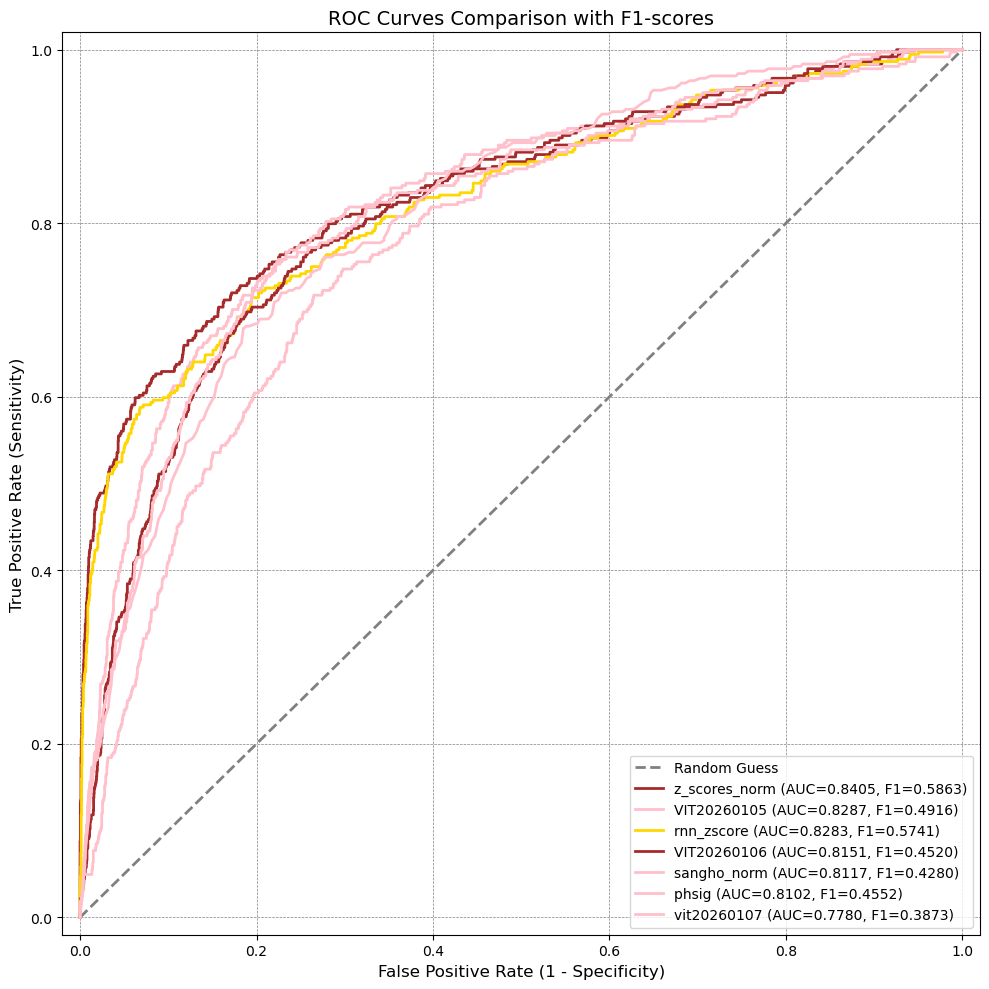


特征性能报告:
按AUC值降序排列，显示最佳F1-score及对应的阈值和虚警率(FPR)
----------------------------------------------------------------------------------------------------
特征名称         AUC值         最佳F1-score      阈值              虚警率(FPR)       
----------------------------------------------------------------------------------------------------
z_scores_norm 0.84052      0.58626         0.58788         0.01896        
VIT20260105  0.82870      0.49161         0.29262         0.08663        
rnn_zscore   0.82829      0.57407         2.16880         0.03204        
VIT20260106  0.81507      0.45200         0.29402         0.08924        
sangho_norm  0.81168      0.42796         0.89737         0.11997        
phsig        0.81019      0.45522         0.34946         0.12063        
vit20260107  0.77796      0.38731         0.40763         0.12194        

按F1-score排序:
----------------------------------------------------------------------------------------------------
特征名称         AUC值         最佳F1-score      阈

In [20]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import roc_curve, auc, f1_score, confusion_matrix

df = pd.read_csv("/data6/WORKDIR/amatrice2025/merged/interferograms/0914/roc精度评价VIT.csv")  # 替换为你的文件路径

# 定义特征列表和颜色配置 decorrelation	TGRS_std	TGRS

features = [
    ("z_scores_norm", "brown"),
    ("VIT20260106", "brown"),
    ("phsig", "pink"),
    ("sangho_norm", "pink"),
    ("vit20260107", "pink"),
    ("VIT20260105", "pink"),
    ("rnn_zscore", "gold")
    
]

# 设置画布
plt.figure(figsize=(10, 10))

# 绘制参考线
plt.plot([0, 1], [0, 1], color='grey', lw=2, linestyle='--', label='Random Guess')

# 创建列表存储计算结果
roc_data = []
f1_results = []  # 存储F1-score结果

# 先计算所有特征的AUC值和F1-score
for feature, color in features:
    y_true = df['damaged']
    y_score = df[feature]
    
    # 计算ROC曲线
    fpr, tpr, thresholds = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)
    
    # 找到最佳F1-score及其阈值
    best_f1 = 0
    best_threshold = 0
    best_fpr = 0
    best_f1_index = 0
    
    # 遍历所有阈值计算F1-score
    for i, threshold in enumerate(thresholds):
        # 使用当前阈值进行预测
        y_pred = (y_score >= threshold).astype(int)
        
        # 计算F1-score
        f1 = f1_score(y_true, y_pred)
        
        # 更新最佳F1-score
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_f1_index = i
    
    # 获取最佳阈值对应的虚警率(FPR)
    if best_f1_index < len(fpr):
        best_fpr = fpr[best_f1_index]
    else:
        # 如果索引越界，使用上一个可用的FPR值
        best_fpr = fpr[-1] if fpr.size > 0 else 0
    
    # 存储特征名、颜色、AUC值以及ROC曲线数据
    roc_data.append({
        'feature': feature,
        'color': color,
        'auc': roc_auc,
        'fpr': fpr,
        'tpr': tpr,
        'best_f1': best_f1,
        'best_threshold': best_threshold,
        'best_fpr': best_fpr
    })
    
    # 存储F1结果用于后续输出
    f1_results.append({
        'feature': feature,
        'auc': roc_auc,
        'best_f1': best_f1,
        'threshold': best_threshold,
        'fpr': best_fpr
    })

# 按AUC值从高到低排序
roc_data_sorted = sorted(roc_data, key=lambda x: x['auc'], reverse=True)

# 按排序后的顺序绘制ROC曲线
for data in roc_data_sorted:
    plt.plot(data['fpr'], data['tpr'], color=data['color'], lw=2,
             label=f"{data['feature']} (AUC={data['auc']:.4f}, F1={data['best_f1']:.4f})")

# 图表装饰
plt.xlim([-0.02, 1.02])
plt.ylim([-0.02, 1.02])
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('ROC Curves Comparison with F1-scores', fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', color='gray', linewidth=0.5)
plt.tight_layout()
plt.savefig('ROC_curves_with_F1_scores.png', dpi=300)
plt.show()

# 打印F1-score和虚警率结果
print("\n特征性能报告:")
print("按AUC值降序排列，显示最佳F1-score及对应的阈值和虚警率(FPR)")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

# 按AUC排序F1结果
f1_results_sorted = sorted(f1_results, key=lambda x: x['auc'], reverse=True)

for result in f1_results_sorted:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))

# 按F1-score排序
f1_results_sorted_by_f1 = sorted(f1_results, key=lambda x: x['best_f1'], reverse=True)

print("\n按F1-score排序:")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

for result in f1_results_sorted_by_f1:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))
# 按虚警率(FPR)排序（升序，即FPR越小越好）
f1_results_sorted_by_fpr = sorted(f1_results, key=lambda x: x['fpr'])

print("\n按虚警率(FPR)排序（从小到大）:")
print("-" * 100)
print("{:<12} {:<12} {:<15} {:<15} {:<15}".format(
    '特征名称', 'AUC值', '最佳F1-score', '阈值', '虚警率(FPR)'))
print("-" * 100)

for result in f1_results_sorted_by_fpr:
    print("{:<12} {:<12.5f} {:<15.5f} {:<15.5f} {:<15.5f}".format(
        result['feature'], 
        result['auc'], 
        result['best_f1'], 
        result['threshold'], 
        result['fpr']))
